# Eggplant Leaf Disease Classification v2

### Transfer Learning with MobileNetV2 + Focal Loss

This notebook trains an image classifier to detect **7 conditions** in eggplant leaves (6 diseases + healthy) using:
- **MobileNetV2** (pretrained on ImageNet) as a feature extractor
- **Soft Categorical Focal Loss** with label smoothing for robust learning
- **Two-phase training (50 epochs total)**: frozen backbone (40 epochs, warmup+cosine) → gentle fine-tuning last 20 layers (10 epochs, warmup+cosine LR, **BatchNorm frozen**)
- **Hybrid augmentation**: offline copies + online augmentation + **MixUp** for strong regularization
- **Dual-pooling head**: GlobalAveragePooling + GlobalMaxPooling concatenated for richer features
- **Best-model safeguard**: after fine-tuning, the best checkpoint from *either* phase is loaded
- **Reliability checks**: optional test-time augmentation (TTA) + bootstrap confidence intervals
- **Float16 TFLite export** for mobile deployment

In [1]:
import tensorflow as tf
import numpy as np
import os
import pathlib
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

2026-03-07 02:45:17.331961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772851517.574004      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772851517.634139      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772851518.133501      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772851518.133550      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772851518.133553      55 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_PATH = "/kaggle/input/datasets/madisoneureka/eggplant-leaves-disease-detection/A Curated Dataset of Eggplant Leaves Healthy Specimens and Six Major Disease Conditions/Eggplant Leaf Image Dataset"

IMG_SIZE = 256                   # ↑ from 224 → better resolution for leaf lesion/spot details
BATCH_SIZE = 32
SEED = 42

# ── Split ratios ──
TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10
TEMP_TEST_FRACTION = TEST_RATIO / (VAL_RATIO + TEST_RATIO)  # ≈ 1/3

# ── Offline augmentation ──
NUM_AUG_COPIES = 5               # ↑ from 3 → more variety for small dataset (x6 total)

# ── Toggleable improvements ──
USE_GLOBAL_SEED = True           # set global random seeds for reproducibility
USE_MODEL_CHECKPOINT = True      # save best model weights during training
USE_GRADIENT_CLIPPING = True     # clip gradients during fine-tuning
GRADIENT_CLIP_NORM = 1.0         # max gradient norm when clipping is enabled
USE_ONLINE_AUGMENTATION = True   # apply random augmentation each epoch on top of offline copies
USE_LABEL_SMOOTHING = True       # smooth one-hot labels for better generalization
LABEL_SMOOTHING_FACTOR = 0.1     # smoothing factor (0.1 is standard)
MODEL_SAVE_DIR = "saved_models"
USE_MIXUP = True                 # MixUp regularization to close train-val gap
MIXUP_ALPHA = 0.3                # Beta distribution param — 0.3 gives moderate blending

# ── Fine-tuning (Phase 2) — gentle to avoid accuracy drop ──
FINE_TUNE_LAYERS = 20            # conservative: only last 20 layers (avoid low-level feature disruption)
FINE_TUNE_EPOCHS = 10            # short: 10 epochs (total 40+10=50)
FINE_TUNE_LR = 5e-6             # very low LR — prevents destabilizing pretrained weights
FINE_TUNE_WARMUP_EPOCHS = 3      # warm up over 3 of the 10 FT epochs

# ── Phase 1 training ──
PHASE1_EPOCHS = 40               # 40 epochs (plateaus ~epoch 40 based on v2 results)
PHASE1_WARMUP_EPOCHS = 5         # warmup for Phase 1 cosine schedule

# ── Evaluation reliability ──
USE_TTA = True                   # test-time augmentation for more stable inference
TTA_RUNS = 7                     # ↑ from 5 → more passes for stable averaging
BOOTSTRAP_SAMPLES = 1000         # CI stability for test metrics

# ── Reproducibility ──
if USE_GLOBAL_SEED:
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

## 1. Configuration & Hyperparameters

In [3]:
# ── Proper 70/20/10 Stratified Split ──
data_dir = pathlib.Path(DATASET_PATH)
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

all_paths = []
all_labels = []
for label, cls in enumerate(class_names):
    cls_paths = list((data_dir / cls).glob("*.*"))
    all_paths.extend([str(p) for p in cls_paths])
    all_labels.extend([label] * len(cls_paths))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

# 70% train, 30% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=1 - TRAIN_RATIO, random_state=SEED, stratify=all_labels
)

# 20% val, 10% test from the 30% temp
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=TEMP_TEST_FRACTION, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

def build_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    def load_image(path, label):
        img = tf.io.read_file(path)
        # FIX: decode_image handles JPEG, PNG, BMP, GIF — not just JPEG
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])  # required after decode_image
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32)  # ensure float32 for augmentation layers
        return img, label
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_paths, train_labels, shuffle=True)
val_ds   = build_dataset(val_paths,   val_labels,   shuffle=False)
test_ds  = build_dataset(test_paths,  test_labels,  shuffle=False)

Classes: ['Healthy', 'Insect_Pest', 'Leaf_Spot', 'Mosaic_Virus', 'Small_Leaf', 'White_Mold', 'Wilt']
Train: 979, Val: 280, Test: 141


I0000 00:00:1772851546.515178      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 3. Exploratory Data Analysis

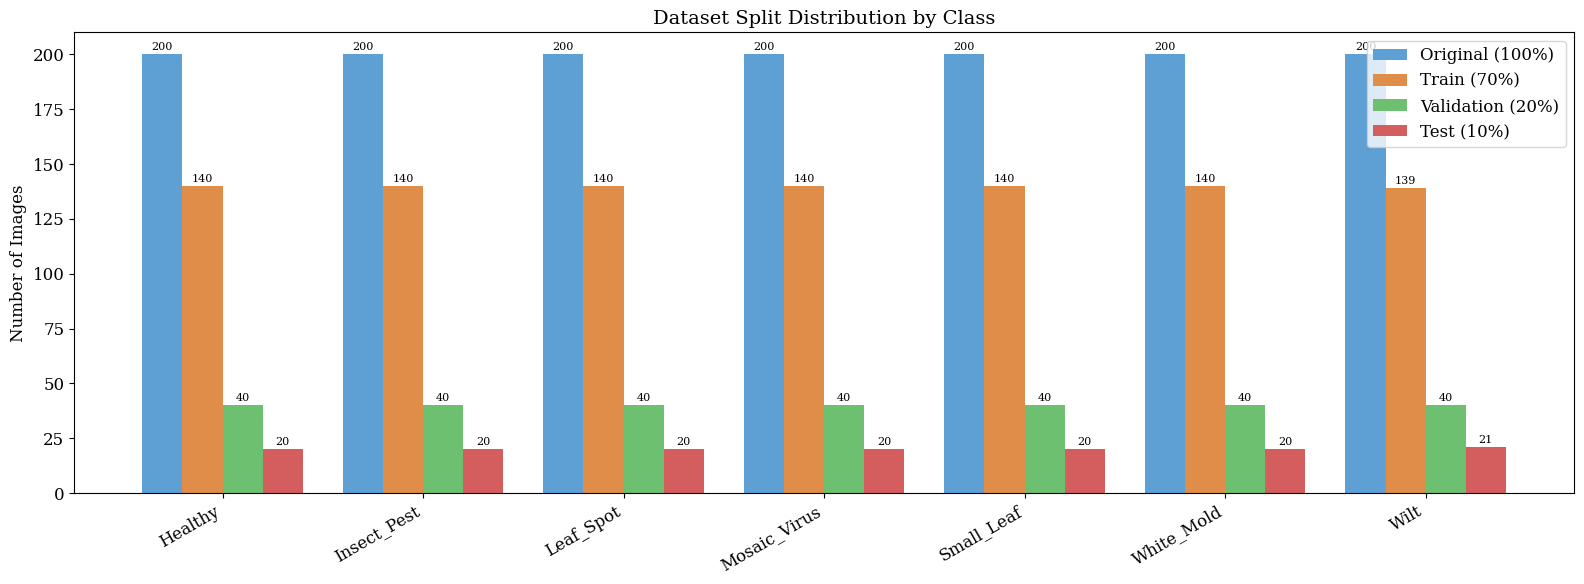


Total images: 1400
Train: 979 | Val: 280 | Test: 141


In [4]:
# ── Data Distribution: Original Split ──
from collections import Counter

orig_counts  = Counter(all_labels)
train_counts = Counter(train_labels)
val_counts   = Counter(val_labels)
test_counts  = Counter(test_labels)

orig_counts_by_name  = [orig_counts[i]  for i in range(NUM_CLASSES)]
train_counts_by_name = [train_counts[i] for i in range(NUM_CLASSES)]
val_counts_by_name   = [val_counts[i]   for i in range(NUM_CLASSES)]
test_counts_by_name  = [test_counts[i]  for i in range(NUM_CLASSES)]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

x = np.arange(NUM_CLASSES)
width = 0.20
fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - 1.5*width, orig_counts_by_name,  width, label="Original (100%)",  color="#5e9fd4")
bars2 = ax.bar(x - 0.5*width, train_counts_by_name, width, label="Train (70%)",      color="#e08d4a")
bars3 = ax.bar(x + 0.5*width, val_counts_by_name,   width, label="Validation (20%)", color="#6cc070")
bars4 = ax.bar(x + 1.5*width, test_counts_by_name,  width, label="Test (10%)",        color="#d45e5e")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylabel("Number of Images")
ax.set_title("Dataset Split Distribution by Class")
ax.legend()
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, str(int(h)),
                ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("data_distribution.png", dpi=300)
plt.show()

print(f"\nTotal images: {len(all_labels)}")
print(f"Train: {len(train_labels)} | Val: {len(val_labels)} | Test: {len(test_labels)}")

## 4. Offline Data Augmentation, MixUp & Class Weighting

**Hybrid augmentation strategy:**
1. **Offline** — generate `NUM_AUG_COPIES` strong augmented copies per training image (with random erasing)
2. **Online** — apply lighter random transforms to every training batch each epoch (different view every pass)
3. **MixUp** — blend pairs of images + labels to create virtual examples; proven to close train-val gaps on small datasets

This gives dataset-size benefit, epoch-to-epoch variety, and interpolation-based regularization.

In [5]:
# ── Offline Data Augmentation (leaf-disease-appropriate transforms) ──
# For leaf disease detection, we must be careful with:
#   - Color augmentations: conservative, because disease symptoms are often
#     colour/texture cues (yellowing, browning, lesions).
#   - Geometric augmentations: moderate flips/rotation/zoom are safe because
#     leaves can appear in many orientations and scales.
#   - Random erasing: teaches the model to classify from partial views
#     (robust to occlusion and forces attention to multiple regions).

data_augmentation_offline = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),             # ↑ slightly from 0.12
    tf.keras.layers.RandomZoom((-0.15, 0.15)),        # ↑ slightly from 0.12
    tf.keras.layers.RandomContrast(0.10),             # ↑ slightly from 0.08
    tf.keras.layers.RandomBrightness(0.08),           # ↑ slightly from 0.06
    tf.keras.layers.RandomTranslation(0.10, 0.10),    # ↑ slightly from 0.08
], name="data_augmentation_offline")

# ── Random erasing function (applied separately per copy) ──
def random_erasing_batch(images, prob=0.5, area_range=(0.02, 0.20)):
    """Apply random erasing (cutout) to a batch of images.
    Fills erased region with per-channel mean — preserves image statistics.
    """
    batch_size = tf.shape(images)[0]
    h = tf.shape(images)[1]
    w = tf.shape(images)[2]

    # Decide which images get erasing
    mask = tf.random.uniform([batch_size]) < prob
    
    # Random area fraction and aspect ratio
    area_frac = tf.random.uniform([batch_size], area_range[0], area_range[1])
    aspect = tf.random.uniform([batch_size], 0.5, 2.0)
    
    eh = tf.cast(tf.math.sqrt(area_frac * tf.cast(h * w, tf.float32) / aspect), tf.int32)
    ew = tf.cast(tf.math.sqrt(area_frac * tf.cast(h * w, tf.float32) * aspect), tf.int32)
    eh = tf.minimum(eh, h - 1)
    ew = tf.minimum(ew, w - 1)
    
    # Random position
    top = tf.random.uniform([batch_size], 0, 1, dtype=tf.float32)
    top = tf.cast(top * tf.cast(h - eh, tf.float32), tf.int32)
    left = tf.random.uniform([batch_size], 0, 1, dtype=tf.float32)
    left = tf.cast(left * tf.cast(w - ew, tf.float32), tf.int32)
    
    # Apply erasing per image
    result = []
    for i in tf.range(batch_size):
        img = images[i]
        if mask[i]:
            # Fill with per-channel mean
            ch_mean = tf.reduce_mean(img, axis=[0, 1], keepdims=True)
            fill = tf.ones_like(img) * ch_mean
            # Create erasing mask
            y_range = tf.range(h)
            x_range = tf.range(w)
            y_mask = tf.logical_and(y_range >= top[i], y_range < top[i] + eh[i])
            x_mask = tf.logical_and(x_range >= left[i], x_range < left[i] + ew[i])
            erase_mask = tf.cast(y_mask[:, None] & x_mask[None, :], tf.float32)[:, :, None]
            img = img * (1.0 - erase_mask) + fill * erase_mask
        result.append(img)
    return tf.stack(result)

# ── Online augmentation (lighter, applied every epoch for variety) ──
data_augmentation_online = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),             # ↑ slightly from 0.06
    tf.keras.layers.RandomZoom((-0.08, 0.08)),        # ↑ slightly from 0.06
    tf.keras.layers.RandomContrast(0.05),             # mild — preserve disease colour
    tf.keras.layers.RandomBrightness(0.04),           # mild — preserve disease colour
    tf.keras.layers.RandomTranslation(0.05, 0.05),    # NEW: slight shift
], name="data_augmentation_online")

# ── MixUp helper (operates on batches with one-hot labels) ──
def mixup_batch(images, labels, alpha=0.3, num_classes=7):
    """Apply MixUp: blend pairs of images and their soft labels.
    Labels are converted to one-hot for blending, then kept as soft targets.
    """
    batch_size = tf.shape(images)[0]
    # Sample mixing coefficient from Beta(alpha, alpha)
    lam = tf.random.gamma([batch_size, 1, 1, 1], alpha=alpha, beta=1.0 / alpha)
    lam = tf.clip_by_value(lam, 0.0, 1.0)
    lam_labels = tf.reshape(lam, [batch_size, 1])

    # Shuffle indices for pairing
    indices = tf.random.shuffle(tf.range(batch_size))
    images_shuffled = tf.gather(images, indices)

    # Convert sparse labels to one-hot
    labels_onehot = tf.one_hot(tf.cast(labels, tf.int32), depth=num_classes)
    labels_shuffled = tf.gather(labels_onehot, indices)

    # Blend
    mixed_images = images * lam + images_shuffled * (1.0 - lam)
    mixed_labels = labels_onehot * lam_labels + labels_shuffled * (1.0 - lam_labels)

    return mixed_images, mixed_labels

print(f"Generating {NUM_AUG_COPIES} offline augmented copies per training image...")

# Load original training images from disk
train_ds_orig = build_dataset(train_paths, train_labels, shuffle=False)

orig_batches_imgs = []
orig_batches_lbls = []
for batch_imgs, batch_lbls in train_ds_orig:
    orig_batches_imgs.append(batch_imgs.numpy())
    orig_batches_lbls.append(batch_lbls.numpy())

orig_images = np.concatenate(orig_batches_imgs, axis=0)
orig_labels_arr = np.concatenate(orig_batches_lbls, axis=0)
del orig_batches_imgs, orig_batches_lbls

n_orig = len(orig_images)
n_total = n_orig * (1 + NUM_AUG_COPIES)
print(f"Original training images: {n_orig}")

# Pre-allocate array for all images (original + augmented)
all_train_images = np.empty((n_total, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
all_train_labels_arr = np.empty(n_total, dtype=orig_labels_arr.dtype)

# Copy originals
all_train_images[:n_orig] = orig_images
all_train_labels_arr[:n_orig] = orig_labels_arr

# Generate augmented copies in batches (with random erasing on ~50% of images)
for copy_idx in range(NUM_AUG_COPIES):
    start = n_orig * (copy_idx + 1)
    for i in range(0, n_orig, BATCH_SIZE):
        batch_end = min(i + BATCH_SIZE, n_orig)
        batch = orig_images[i:batch_end]
        augmented = data_augmentation_offline(batch, training=True)
        # Apply random erasing to this batch
        augmented = random_erasing_batch(augmented, prob=0.4).numpy()
        np.clip(augmented, 0, 255, out=augmented)  # keep pixels in valid range
        all_train_images[start + i : start + batch_end] = augmented
    all_train_labels_arr[start : start + n_orig] = orig_labels_arr
    print(f"  ✓ Copy {copy_idx + 1}/{NUM_AUG_COPIES} generated (with random erasing)")

del orig_images  # free memory

# Store augmented labels for charts
train_labels_augmented = all_train_labels_arr.copy()

# Build augmented training dataset with optional online augmentation + MixUp
def make_train_ds(images, labels, online_aug=True, use_mixup=True):
    """Build training tf.data.Dataset with optional online augmentation and MixUp."""
    ds = (
        tf.data.Dataset.from_tensor_slices((images, labels))
        .shuffle(buffer_size=len(images), seed=SEED, reshuffle_each_iteration=True)
        .batch(BATCH_SIZE, drop_remainder=True)  # drop_remainder for consistent MixUp
    )
    if online_aug and USE_ONLINE_AUGMENTATION:
        def augment_batch(imgs, lbls):
            imgs = data_augmentation_online(imgs, training=True)
            imgs = tf.clip_by_value(imgs, 0.0, 255.0)
            return imgs, lbls
        ds = ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
    if use_mixup and USE_MIXUP:
        def apply_mixup(imgs, lbls):
            return mixup_batch(imgs, lbls, alpha=MIXUP_ALPHA, num_classes=NUM_CLASSES)
        ds = ds.map(apply_mixup, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_train_ds(all_train_images, all_train_labels_arr, online_aug=True)

print(f"\n✓ Offline augmentation complete!")
print(f"  Total training images: {n_total} ({n_orig} original + {n_orig * NUM_AUG_COPIES} augmented)")
print(f"  Online augmentation: {'ON' if USE_ONLINE_AUGMENTATION else 'OFF'}")
print(f"  MixUp (α={MIXUP_ALPHA}): {'ON' if USE_MIXUP else 'OFF'}")
print(f"  Random erasing: ON (prob=0.4)")
print(f"  Memory: {all_train_images.nbytes / (1024**3):.2f} GB")

# Keep all_train_images/labels alive — needed to rebuild train_ds for fine-tuning
import gc; gc.collect()

Generating 5 offline augmented copies per training image...
Original training images: 979
  ✓ Copy 1/5 generated (with random erasing)
  ✓ Copy 2/5 generated (with random erasing)
  ✓ Copy 3/5 generated (with random erasing)
  ✓ Copy 4/5 generated (with random erasing)
  ✓ Copy 5/5 generated (with random erasing)

✓ Offline augmentation complete!
  Total training images: 5874 (979 original + 4895 augmented)
  Online augmentation: ON
  MixUp (α=0.3): ON
  Random erasing: ON (prob=0.4)
  Memory: 4.30 GB


133

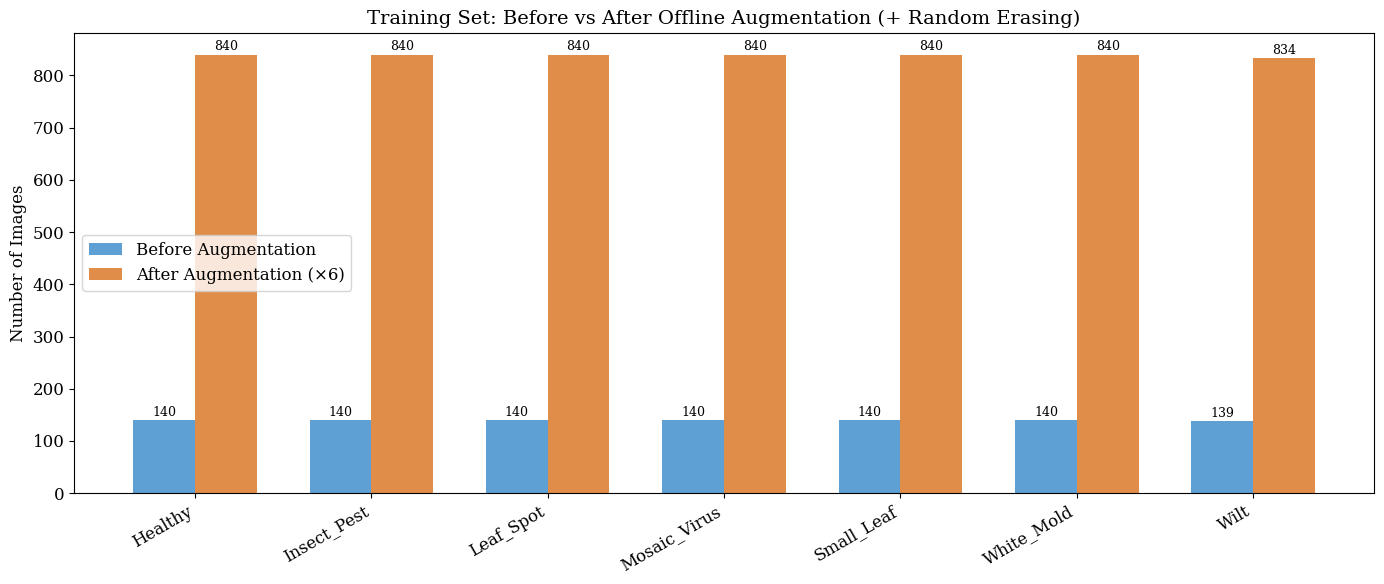

Total before: 979 → After: 5874 (×6 increase)
Online augmentation during training: ON
MixUp regularization (α=0.3): ON


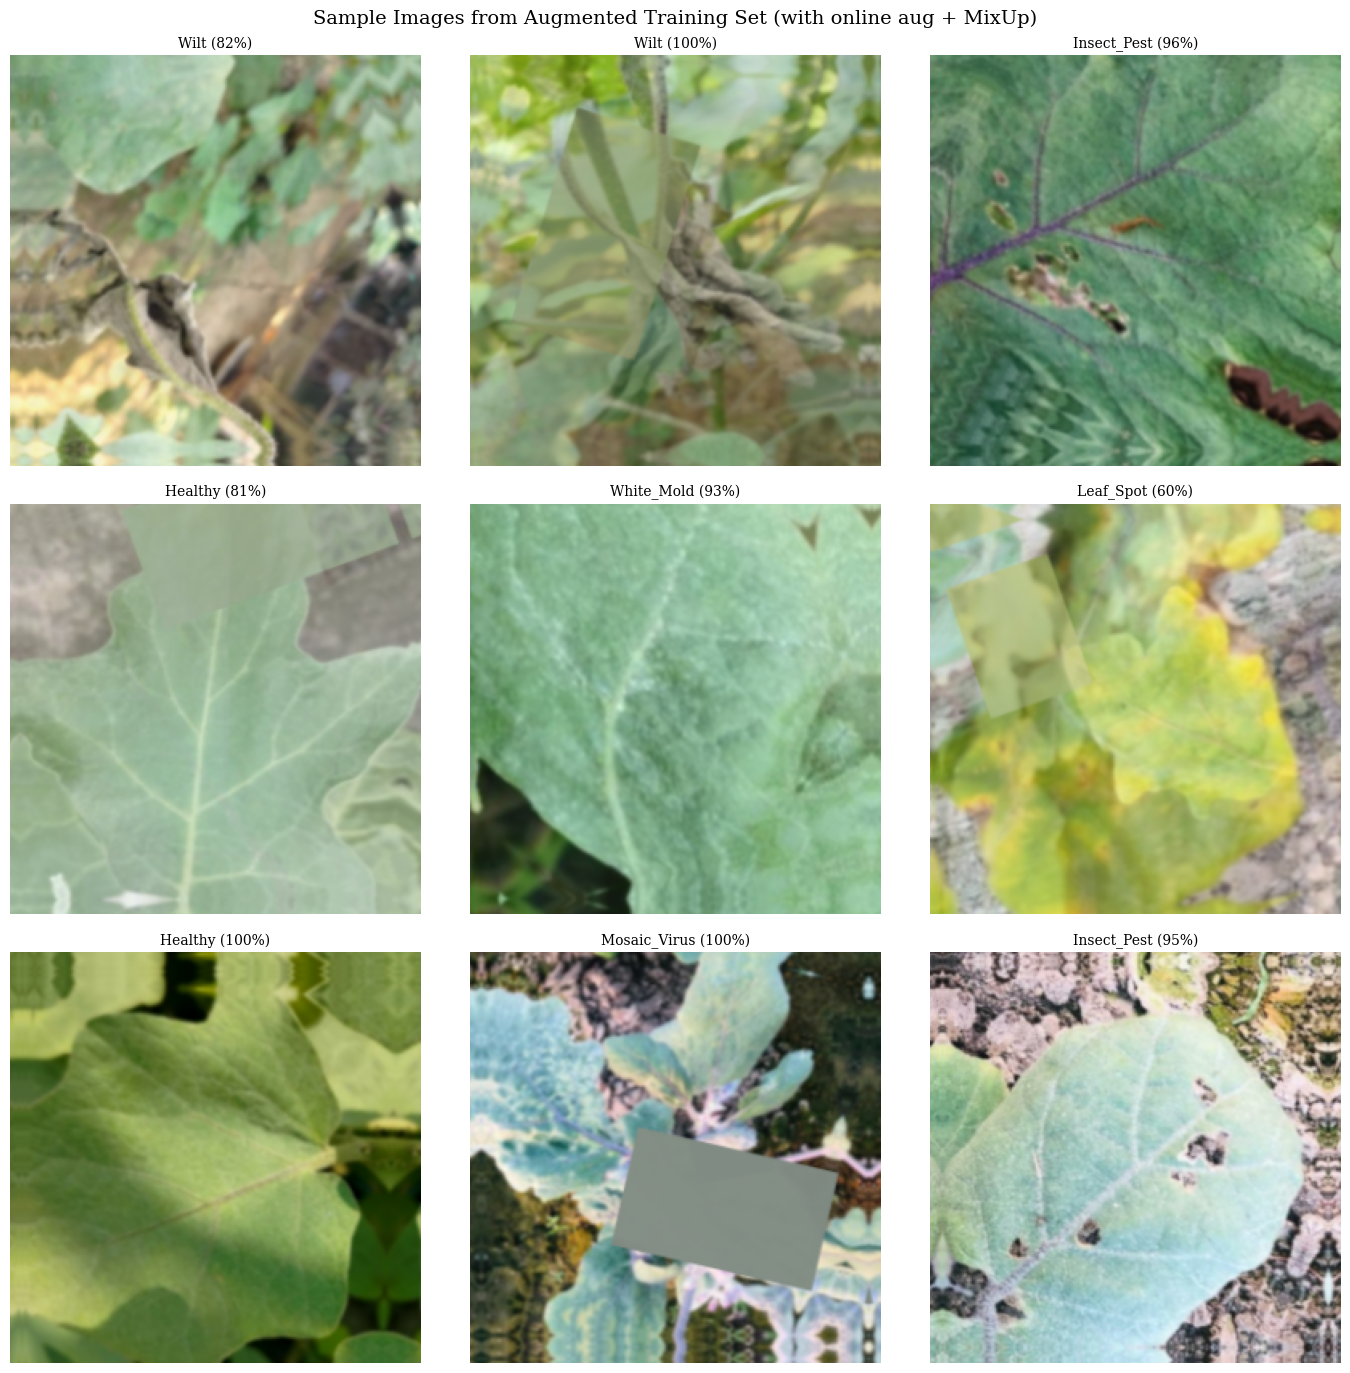

In [6]:
# ── Before vs After Augmentation Chart + Visual Validation ──
from collections import Counter

before_counts = Counter(train_labels)
after_counts  = Counter(train_labels_augmented)

before_by_class = [before_counts[i] for i in range(NUM_CLASSES)]
after_by_class  = [after_counts[i]  for i in range(NUM_CLASSES)]

# ── Bar chart: Before vs After offline augmentation ──
x = np.arange(NUM_CLASSES)
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, before_by_class, width,
               label="Before Augmentation", color="#5e9fd4")
bars2 = ax.bar(x + width/2, after_by_class,  width,
               label=f"After Augmentation (×{1 + NUM_AUG_COPIES})", color="#e08d4a")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylabel("Number of Images")
ax.set_title("Training Set: Before vs After Offline Augmentation (+ Random Erasing)")
ax.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 2, str(int(h)),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("augmentation_before_after.png", dpi=300)
plt.show()

print(f"Total before: {sum(before_by_class)} → After: {sum(after_by_class)} "
      f"(×{1 + NUM_AUG_COPIES} increase)")
print(f"Online augmentation during training: {'ON' if USE_ONLINE_AUGMENTATION else 'OFF'}")
print(f"MixUp regularization (α={MIXUP_ALPHA}): {'ON' if USE_MIXUP else 'OFF'}")

# ── Visual validation: 3×3 grid of samples from the augmented dataset ──
sample_batch, sample_lbls = next(iter(train_ds))

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle("Sample Images from Augmented Training Set (with online aug + MixUp)", fontsize=14)
for idx, ax in enumerate(axes.flat):
    if idx >= sample_batch.shape[0]:
        ax.axis("off")
        continue
    ax.imshow(sample_batch[idx].numpy().astype("uint8"))
    # MixUp produces soft labels — show dominant class
    if sample_lbls.ndim > 1:
        lbl_idx = np.argmax(sample_lbls[idx].numpy())
        confidence = sample_lbls[idx].numpy()[lbl_idx] * 100
        ax.set_title(f"{class_names[lbl_idx]} ({confidence:.0f}%)", fontsize=10)
    else:
        ax.set_title(f"{class_names[sample_lbls[idx]]}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("augmentation_samples.png", dpi=300)
plt.show()

In [7]:
# ── Class Weights (informational only — NOT used in loss) ──
# The dataset is perfectly balanced (~200 per class), so class weights are all ≈ 1.0.
# Per-class alpha weighting in the loss would add no value; removed to simplify.
# Focal loss gamma alone handles easy/hard example re-weighting.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = {int(k): float(v) for k, v in enumerate(class_weights)}
print("Class Weights (informational — not used in loss):", class_weights)
print("Note: All weights ≈ 1.0 → dataset is balanced. Focal loss gamma handles hard examples.")

Class Weights (informational — not used in loss): {0: 0.9989795918367347, 1: 0.9989795918367347, 2: 0.9989795918367347, 3: 0.9989795918367347, 4: 0.9989795918367347, 5: 0.9989795918367347, 6: 1.0061664953751284}
Note: All weights ≈ 1.0 → dataset is balanced. Focal loss gamma handles hard examples.


In [8]:
# ── Hyperparameters ──
BEST_UNITS_1 = 512             # ↑ from 256 → more capacity (needed for dual-pooling 2560-dim input)
BEST_UNITS_2 = 256             # ↑ from 128 → richer representations before final softmax
BEST_DROPOUT = 0.5             # ↑ from 0.4 → stronger regularization to close train-val gap
BEST_LEARNING_RATE = 3e-4      # ↑ from 1e-4 → higher peak LR with warmup+cosine schedule
L2_REG = 5e-4                  # ↑ from 1e-4 → stronger weight decay for small dataset

## 5. Model Architecture

MobileNetV2 with a **dual-pooling** classification head:
- `Rescaling([-1,1])` → `MobileNetV2` → **`GlobalAveragePooling2D ⊕ GlobalMaxPooling2D`** → `BatchNorm` → `Dense(512, ReLU, L2)` → `Dropout(0.5)` → `Dense(256, ReLU, L2)` → `Dropout(0.4)` → `Softmax`
- **Dual pooling** concatenates mean (diffuse patterns like mold) + max (localized lesions/spots) spatial activations → 2560-dim feature vector
- Stronger L2 (5e-4) and dropout (0.5/0.4) to regularize the larger head on a small dataset

In [9]:
# ── Build Model (dual-pooling head, no augmentation in graph) ──
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# Clip to [0, 255] and normalize to [-1, 1] for MobileNetV2
x = tf.keras.layers.ReLU(max_value=255.0, name="clip_pixels")(inputs)
x = tf.keras.layers.Rescaling(scale=1.0/127.5, offset=-1.0, name="preprocess")(x)
x = base_model(x, training=False)

# ── Dual-pooling: GlobalAvg captures diffuse patterns, GlobalMax captures localized lesions ──
gap = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
gmp = tf.keras.layers.GlobalMaxPooling2D(name="global_max_pool")(x)
x = tf.keras.layers.Concatenate(name="dual_pool")([gap, gmp])  # 1280+1280 = 2560-dim

x = tf.keras.layers.BatchNormalization()(x)

# First FC block
x = tf.keras.layers.Dense(
    BEST_UNITS_1,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(L2_REG)
)(x)
x = tf.keras.layers.Dropout(BEST_DROPOUT)(x)

# Second FC block — gives deeper representation for 7-class discrimination
x = tf.keras.layers.Dense(
    BEST_UNITS_2,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(L2_REG)
)(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

/tmp/ipykernel_55/4251948912.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip_pixels (ReLU)  │ (None, 256, 256,  │          0 │ input_layer_3[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocess          │ (None, 256, 256,  │          0 │ clip_pixels[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 8, 8,      │  2,257,984 │ preprocess[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dual_pool           │ (None, 2560)      │          0 │ global_avg_pool[… │
│ (Concatenate)       │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2560)      │     10,240 │ dual_pool[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7)         │      1,799 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,712,583 (14.16 MB)

 Trainable params: 1,449,479 (5.53 MB)

 Non-trainable params: 2,263,104 (8.63 MB)

In [10]:
# ── Validate Model Architecture ──
trainable   = sum(1 for l in model.layers if l.trainable)
non_trainable = sum(1 for l in model.layers if not l.trainable)

print(f"Total model layers: {len(model.layers)}")
print(f"Trainable layers: {trainable}, Frozen layers: {non_trainable}")
print(f"Input shape:  {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"Total params: {model.count_params():,}")

Total model layers: 13
Trainable layers: 12, Frozen layers: 1
Input shape:  (None, 256, 256, 3)
Output shape: (None, 7)
Total params: 3,712,583


In [11]:
# ── Focal Loss with Label Smoothing + MixUp Soft-Label Support ──
@tf.keras.utils.register_keras_serializable(package="Custom")
class SoftCategoricalFocalLoss(tf.keras.losses.Loss):
    """Focal loss that accepts BOTH sparse integer labels AND soft/one-hot labels.
    
    Required for MixUp, which produces soft (blended) label vectors.
    Falls back to standard sparse behaviour when labels are rank-1 integers.

    Args:
        gamma: Focusing parameter (>=0). Default 2.0 (Lin et al., 2017).
        label_smoothing: Fraction of probability mass distributed uniformly
                         across all classes (0 = no smoothing).
        epsilon: Small constant for numerical stability.
    """

    def __init__(self, gamma=2.0, label_smoothing=0.0, epsilon=1e-7, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.epsilon = epsilon

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, self.epsilon, 1.0 - self.epsilon)
        num_classes = tf.shape(y_pred)[-1]

        # --- Handle both sparse (int) and soft (one-hot/MixUp) labels ---
        if y_true.shape.rank == 1 or (y_true.shape.rank == 2 and y_true.shape[-1] == 1):
            # Sparse integer labels → convert to one-hot
            y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
            y_true_soft = tf.one_hot(y_true, depth=num_classes)
        else:
            # Already soft labels (from MixUp)
            y_true_soft = tf.cast(y_true, tf.float32)

        # Label smoothing: soft targets reduce overconfidence
        if self.label_smoothing > 0:
            y_true_soft = (
                y_true_soft * (1.0 - self.label_smoothing)
                + self.label_smoothing / tf.cast(num_classes, tf.float32)
            )

        cross_entropy = -y_true_soft * tf.math.log(y_pred)
        focal_weight = y_true_soft * tf.pow(1.0 - y_pred, self.gamma)
        focal_loss = focal_weight * cross_entropy
        return tf.reduce_sum(focal_loss, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "gamma": self.gamma,
            "label_smoothing": self.label_smoothing,
            "epsilon": self.epsilon,
        })
        return config

## 6. Training

**Phase 1 — Feature extraction** (backbone frozen, 40 epochs, warmup+cosine decay from 3e-4)
**Phase 2 — Gentle fine-tuning** (last 20 backbone layers unfrozen, BatchNorm frozen, 10 epochs, warmup+cosine decay from 5e-6, gradient clipping)
**Total: 50 epochs**

Key improvements over v1:
- **MixUp regularization** (α=0.3) blends image pairs → virtual training examples close the train-val gap
- **Dual pooling** (GAP+GMP) captures both diffuse and localized disease features
- **Warmup + cosine decay** for both phases → smoother convergence than ReduceLROnPlateau
- **Stronger regularization**: dropout 0.5/0.4, L2=5e-4, random erasing
- **Frozen BatchNorm** during fine-tuning → prevents accuracy drop from running stats shift
- **Higher resolution** (256px) preserves small lesion/spot details
- **No class weights** in loss — dataset is balanced; focal gamma alone handles hard examples
- **Best-model safeguard**: loads whichever checkpoint (Phase 1 or 2) has lower val_loss

In [12]:
# ── Phase 1: Initial Training (backbone frozen, warmup + cosine decay) ──

# Custom accuracy metric that works with both soft (MixUp) and sparse labels
class SoftAccuracy(tf.keras.metrics.Metric):
    """Accuracy metric that handles both soft (MixUp) and sparse integer labels."""
    def __init__(self, name="accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_variable(shape=(), initializer="zeros", name="correct")
        self.total = self.add_variable(shape=(), initializer="zeros", name="total")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Get predicted class
        pred_class = tf.argmax(y_pred, axis=-1)
        # Get true class (handles both soft and sparse)
        if y_true.shape.rank == 1 or (y_true.shape.rank == 2 and y_true.shape[-1] == 1):
            true_class = tf.cast(tf.reshape(y_true, [-1]), tf.int64)
        else:
            true_class = tf.argmax(y_true, axis=-1)
        matches = tf.cast(tf.equal(pred_class, true_class), tf.float32)
        self.correct.assign(self.correct + tf.reduce_sum(matches))
        self.total.assign(self.total + tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return self.correct / (self.total + 1e-7)

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)

def make_callbacks(phase="initial"):
    """Return a fresh list of callbacks for the given training phase.
    No ReduceLROnPlateau — using warmup+cosine decay schedule instead.
    """
    cbs = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,          # ↑ from 10 → cosine schedule needs more patience
            min_delta=1e-4,
            restore_best_weights=True
        ),
    ]
    if USE_MODEL_CHECKPOINT:
        os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
        cbs.append(
            tf.keras.callbacks.ModelCheckpoint(
                filepath=os.path.join(MODEL_SAVE_DIR, f"best_{phase}.keras"),
                monitor="val_loss",
                save_best_only=True,
                verbose=1,
            )
        )
    return cbs

# ── Warmup + Cosine Decay Schedule ──
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup for `warmup_steps`, then cosine decay to `alpha`."""
    def __init__(self, initial_lr, warmup_steps, total_steps, alpha=1e-7):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.alpha = alpha

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        total_steps = tf.cast(self.total_steps, tf.float32)

        # Linear warmup
        warmup_lr = self.initial_lr * (step / tf.maximum(warmup_steps, 1.0))

        # Cosine decay after warmup
        decay_step = step - warmup_steps
        decay_total = total_steps - warmup_steps
        cosine_frac = 0.5 * (1.0 + tf.math.cos(
            np.pi * tf.minimum(decay_step / tf.maximum(decay_total, 1.0), 1.0)
        ))
        cosine_lr = self.alpha + (self.initial_lr - self.alpha) * cosine_frac

        return tf.where(step < warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "alpha": self.alpha,
        }

# Build loss — no class weights (dataset is balanced)
smooth = LABEL_SMOOTHING_FACTOR if USE_LABEL_SMOOTHING else 0.0
loss_fn = SoftCategoricalFocalLoss(gamma=2.0, label_smoothing=smooth)

# Warmup + cosine decay for Phase 1
steps_per_epoch_p1 = len(train_ds)
warmup_steps_p1 = PHASE1_WARMUP_EPOCHS * steps_per_epoch_p1
total_steps_p1 = PHASE1_EPOCHS * steps_per_epoch_p1

phase1_schedule = WarmupCosineDecay(
    initial_lr=BEST_LEARNING_RATE,
    warmup_steps=warmup_steps_p1,
    total_steps=total_steps_p1,
    alpha=1e-6,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=phase1_schedule),
    loss=loss_fn,
    metrics=[SoftAccuracy()]
)

initial_callbacks = make_callbacks(phase="initial")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=initial_callbacks
)

# Record Phase 1 best val_loss for comparison after fine-tuning
phase1_best_val_loss = min(history.history["val_loss"])
print(f"\n✓ Phase 1 complete — best val_loss: {phase1_best_val_loss:.5f}")

Epoch 1/40


I0000 00:00:1772851627.147904     120 service.cc:152] XLA service 0x48f324c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772851627.147974     120 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772851629.425163     120 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772851638.522764     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.1663 - loss: 2.5777
Epoch 1: val_loss improved from inf to 1.31686, saving model to saved_models/best_initial.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 87s 364ms/step - accuracy: 0.1665 - loss: 2.5763 - val_accuracy: 0.4679 - val_loss: 1.3169
Epoch 2/40
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.3668 - loss: 1.6380
Epoch 2: val_loss improved from 1.31686 to 0.99401, saving model to saved_models/best_initial.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 53s 282ms/step - accuracy: 0.3671 - loss: 1.6374 - val_accuracy: 0.6964 - val_loss: 0.9940
Epoch 3/40
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.5300 - loss: 1.2774
Epoch 3: val_loss improved from 0.99401 to 0.91760, saving model to saved_models/best_initial.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 53s 284ms/step - accuracy: 0.5301 - loss: 1.2773 - val_accuracy: 0.7250 - val_loss: 0.9176
Epoch 4/40
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6178 - loss: 1.1113
Epo

In [13]:
# ── Phase 2: Gentle Fine-Tuning (frozen BatchNorm, warmup + cosine decay) ──
# Key: freezing BatchNorm layers prevents running mean/variance shift,
# which is the #1 cause of accuracy drops when fine-tuning starts.

# --- 1. Unfreeze last FINE_TUNE_LAYERS of the backbone (but freeze all BN) ---
fine_tune_base = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
        fine_tune_base = layer
        break

if fine_tune_base is None:
    raise ValueError("Could not find MobileNetV2 layer in the model.")

fine_tune_base.trainable = True

# Freeze everything except the last FINE_TUNE_LAYERS
for layer in fine_tune_base.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

# CRITICAL: Freeze ALL BatchNorm layers in the backbone to prevent accuracy drop
bn_frozen = 0
for layer in fine_tune_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        bn_frozen += 1

trainable_backbone = sum(1 for l in fine_tune_base.layers if l.trainable)
print(f"Fine-tuning {trainable_backbone} backbone layers (last {FINE_TUNE_LAYERS} unfrozen)")
print(f"Frozen {bn_frozen} BatchNorm layers in backbone (prevents accuracy drop)")

# --- 2. Warmup + Cosine decay schedule ---
initial_epochs_done = len(history.history["loss"])
total_fine_tune_epochs = initial_epochs_done + FINE_TUNE_EPOCHS

# Rebuild train_ds for fine-tuning (needed to compute steps)
train_ds_ft = make_train_ds(all_train_images, all_train_labels_arr, online_aug=True)
steps_per_epoch_ft = len(train_ds_ft)

warmup_steps_ft = FINE_TUNE_WARMUP_EPOCHS * steps_per_epoch_ft
total_steps_ft = FINE_TUNE_EPOCHS * steps_per_epoch_ft

ft_schedule = WarmupCosineDecay(
    initial_lr=FINE_TUNE_LR,
    warmup_steps=warmup_steps_ft,
    total_steps=total_steps_ft,
    alpha=1e-7,
)

optimizer_kwargs = {"learning_rate": ft_schedule}
if USE_GRADIENT_CLIPPING:
    optimizer_kwargs["clipnorm"] = GRADIENT_CLIP_NORM

model.compile(
    optimizer=tf.keras.optimizers.Adam(**optimizer_kwargs),
    loss=SoftCategoricalFocalLoss(gamma=2.0, label_smoothing=smooth),
    metrics=[SoftAccuracy()]
)

# --- 3. Fresh callbacks for fine-tuning ---
ft_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        min_delta=1e-4,
        restore_best_weights=True
    ),
]
if USE_MODEL_CHECKPOINT:
    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
    ft_callbacks.append(
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(MODEL_SAVE_DIR, "best_finetune.keras"),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        )
    )

fine_tune_history = model.fit(
    train_ds_ft,
    validation_data=val_ds,
    epochs=total_fine_tune_epochs,
    initial_epoch=initial_epochs_done,
    callbacks=ft_callbacks
)

# --- 4. Best-model safeguard ---
phase2_best_val_loss = min(fine_tune_history.history["val_loss"])
print(f"\nPhase 1 best val_loss: {phase1_best_val_loss:.5f}")
print(f"Phase 2 best val_loss: {phase2_best_val_loss:.5f}")

if phase1_best_val_loss <= phase2_best_val_loss:
    best_path = os.path.join(MODEL_SAVE_DIR, "best_initial.keras")
    print(f"⚠ Fine-tuning did NOT improve over Phase 1 → loading {best_path}")
else:
    best_path = os.path.join(MODEL_SAVE_DIR, "best_finetune.keras")
    print(f"✓ Fine-tuning improved val_loss by {phase1_best_val_loss - phase2_best_val_loss:.5f}")

model = tf.keras.models.load_model(
    best_path,
    custom_objects={
        "SoftCategoricalFocalLoss": SoftCategoricalFocalLoss,
        "SoftAccuracy": SoftAccuracy,
    }
)
print(f"  Loaded best model from: {best_path}")

# Free the large numpy arrays now that training is complete
del all_train_images, all_train_labels_arr
import gc; gc.collect()

Fine-tuning 13 backbone layers (last 20 unfrozen)
Frozen 52 BatchNorm layers in backbone (prevents accuracy drop)
Epoch 41/50


2026-03-07 03:22:57.110853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:22:57.310416: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:22:57.510603: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8918 - loss: 0.4926
Epoch 41: val_loss improved from inf to 0.49808, saving model to saved_models/best_finetune.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 86s 341ms/step - accuracy: 0.8917 - loss: 0.4927 - val_accuracy: 0.8714 - val_loss: 0.4981
Epoch 42/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8898 - loss: 0.4947
Epoch 42: val_loss improved from 0.49808 to 0.49388, saving model to saved_models/best_finetune.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 53s 281ms/step - accuracy: 0.8898 - loss: 0.4947 - val_accuracy: 0.8750 - val_loss: 0.4939
Epoch 43/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8893 - loss: 0.4935
Epoch 43: val_loss did not improve from 0.49388
183/183 ━━━━━━━━━━━━━━━━━━━━ 52s 280ms/step - accuracy: 0.8893 - loss: 0.4935 - val_accuracy: 0.8750 - val_loss: 0.4955
Epoch 44/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9028 - loss: 0.4913
Epoch 44: val_loss improved from 0.49388 to 0.49

TypeError: <class 'keras.src.optimizers.adam.Adam'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': {'module': None, 'class_name': 'WarmupCosineDecay', 'config': {'initial_lr': 5e-06, 'warmup_steps': 549, 'total_steps': 1830, 'alpha': 1e-07}, 'registered_name': 'WarmupCosineDecay'}, 'weight_decay': None, 'clipnorm': 1.0, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}.

Exception encountered: Could not locate class 'WarmupCosineDecay'. Make sure custom classes are decorated with `@keras.saving.r

In [ ]:
# Recompile with fresh loss for evaluation (loaded model may have stale references)
smooth = LABEL_SMOOTHING_FACTOR if USE_LABEL_SMOOTHING else 0.0
model.compile(
    optimizer=model.optimizer,
    loss=SoftCategoricalFocalLoss(gamma=2.0, label_smoothing=smooth),
    metrics=["accuracy"]  # standard accuracy is fine for eval (sparse labels)
)

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

## 7. Evaluation, Reliability & Visualization

In [ ]:
# ── Robust Evaluation: Single-pass vs TTA + Bootstrap CIs ──
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_true = np.concatenate([y.numpy() for _, y in test_ds])

single_pass_probs = model.predict(test_ds, verbose=0)
single_pass_pred = np.argmax(single_pass_probs, axis=1)

def make_tta_augmentor():
    # Keep TTA transformations mild and geometry-focused for leaf disease cues.
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.04),
        tf.keras.layers.RandomZoom((-0.04, 0.04)),
        tf.keras.layers.RandomTranslation(0.03, 0.03),
    ], name="tta_augmentor")

def predict_with_tta(model, dataset, runs=5):
    tta_aug = make_tta_augmentor()
    all_run_probs = []
    for _ in range(runs):
        batch_probs = []
        for imgs, _ in dataset:
            aug_imgs = tta_aug(imgs, training=True)
            batch_probs.append(model.predict_on_batch(aug_imgs))
        all_run_probs.append(np.concatenate(batch_probs, axis=0))
    return np.mean(np.stack(all_run_probs, axis=0), axis=0)

if USE_TTA:
    y_pred_probs = predict_with_tta(model, test_ds, runs=TTA_RUNS)
    eval_mode = f"TTA (runs={TTA_RUNS})"
else:
    y_pred_probs = single_pass_probs
    eval_mode = "single-pass"

y_pred = np.argmax(y_pred_probs, axis=1)

single_acc = accuracy_score(y_true, single_pass_pred)
single_f1 = f1_score(y_true, single_pass_pred, average="macro")
final_acc = accuracy_score(y_true, y_pred)
final_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Single-pass  -> accuracy: {single_acc:.4f}, macro F1: {single_f1:.4f}")
print(f"{eval_mode:<12} -> accuracy: {final_acc:.4f}, macro F1: {final_f1:.4f}")

def bootstrap_ci(y_true_arr, y_pred_arr, scorer, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true_arr)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        scores.append(scorer(y_true_arr[idx], y_pred_arr[idx]))
    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)

acc_mean, acc_lo, acc_hi = bootstrap_ci(
    y_true, y_pred, accuracy_score, n_bootstrap=BOOTSTRAP_SAMPLES, seed=SEED
)
f1_mean, f1_lo, f1_hi = bootstrap_ci(
    y_true,
    y_pred,
    lambda yt, yp: f1_score(yt, yp, average="macro"),
    n_bootstrap=BOOTSTRAP_SAMPLES,
    seed=SEED + 1,
)

print(f"Bootstrap (n={BOOTSTRAP_SAMPLES}) Accuracy CI: {acc_lo:.4f}–{acc_hi:.4f} (mean={acc_mean:.4f})")
print(f"Bootstrap (n={BOOTSTRAP_SAMPLES}) Macro-F1 CI: {f1_lo:.4f}–{f1_hi:.4f} (mean={f1_mean:.4f})")

per_class_recall = recall_score(y_true, y_pred, labels=range(NUM_CLASSES), average=None, zero_division=0)
weakest_idx = np.argsort(per_class_recall)[:2]
print("Lowest-recall classes (priority for new real data collection):")
for i in weakest_idx:
    print(f"  - {class_names[i]}: recall={per_class_recall[i]:.4f}")

In [ ]:
# ── Publication-quality plot settings ──
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# FIX: Renamed variables to avoid shadowing `loss, acc` from model.evaluate()
train_acc = history.history["accuracy"]      + fine_tune_history.history["accuracy"]
val_acc   = history.history["val_accuracy"]  + fine_tune_history.history["val_accuracy"]
train_loss = history.history["loss"]          + fine_tune_history.history["loss"]
val_loss   = history.history["val_loss"]      + fine_tune_history.history["val_loss"]
ft_epoch   = len(history.history["accuracy"])  # fine-tuning start

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_acc, label="Train Accuracy")
ax1.plot(val_acc, label="Val Accuracy")
ax1.axvline(ft_epoch, color="gray", linestyle="--", label="Fine-tuning Start")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_loss, label="Train Loss")
ax2.plot(val_loss, label="Val Loss")
ax2.axvline(ft_epoch, color="gray", linestyle="--", label="Fine-tuning Start")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=300)
plt.show()

# Print summary statistics
print(f"Initial training: {ft_epoch} epochs")
print(f"Fine-tuning: {len(train_acc) - ft_epoch} epochs")
print(f"Best val accuracy: {max(val_acc):.4f} (epoch {np.argmax(val_acc) + 1})")
print(f"Best val loss:     {min(val_loss):.4f} (epoch {np.argmin(val_loss) + 1})")

In [ ]:
# ── Predictions on test set ──
if "y_true" not in globals() or "y_pred_probs" not in globals() or "y_pred" not in globals():
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    eval_mode = "single-pass (fallback)"

print(f"Using predictions from: {eval_mode}")

# ── Text report ──
report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report_text)

# ── Heatmap of classification report ──
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES)
)
report_df = np.array([precision, recall, f1]).T

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    report_df,
    annot=True,
    fmt=".2f",
    xticklabels=["Precision", "Recall", "F1-Score"],
    yticklabels=class_names,
    cmap="YlGnBu",
    ax=ax,
)
ax.set_title("Classification Report Heatmap")
plt.tight_layout()
plt.savefig("classification_report_heatmap.png", dpi=300)
plt.show()

In [ ]:
# ── Confusion Matrix ──
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title("Confusion Matrix (Counts)")
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title("Confusion Matrix (Normalized)")
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
# ── Per-class Accuracy ──
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, per_class_acc, color=sns.color_palette("YlGnBu", NUM_CLASSES))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy")
for bar, v in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.2f}",
            ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=300)
plt.show()

In [ ]:
# ── Sample Predictions Grid ──
test_images, sample_test_labels = next(iter(test_ds))
preds = model.predict(test_images)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, ax in enumerate(axes.flat):
    if i >= len(test_images):
        ax.axis("off")
        continue
    ax.imshow(test_images[i].numpy().astype("uint8"))
    true_label = class_names[sample_test_labels[i]]
    pred_label = class_names[np.argmax(preds[i])]
    confidence = np.max(preds[i]) * 100
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"T: {true_label}\nP: {pred_label} ({confidence:.1f}%)",
                 fontsize=9, color=color)
    ax.axis("off")
plt.suptitle("Sample Predictions", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Export to TFLite

Since augmentation is applied offline (not embedded in the model graph), the training model can be converted directly to TFLite — no need to rebuild a separate inference model.

In [ ]:
# ── Export to TFLite ──
# No augmentation layers in the model — convert directly.
# Dropout is automatically disabled in inference mode by the converter.

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_path = "eggplant_model_float16.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"TFLite model saved: {tflite_path} ({size_mb:.2f} MB)")

# Also save the full Keras model
keras_path = os.path.join(MODEL_SAVE_DIR, "eggplant_final.keras")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
model.save(keras_path)
print(f"Full Keras model saved: {keras_path}")